In [ ]:
import os
import shutil

base_dir = "/content/tiny-imagenet-200"
val_dir = os.path.join(base_dir, "val")
images_dir = os.path.join(val_dir, "images")
ann_file = os.path.join(val_dir, "val_annotations.txt")

# Read annotations
with open(ann_file) as f:
    annotations = [line.strip().split('\t') for line in f]

# Create class folders and move images
for img, cls, *_ in annotations:
    cls_dir = os.path.join(val_dir, cls)
    os.makedirs(cls_dir, exist_ok=True)
    shutil.move(
        os.path.join(images_dir, img),
        os.path.join(cls_dir, img)
    )

os.rmdir(images_dir)

In [ ]:
import tensorflow as tf
import tensorflow.keras.layers as tfla
import tensorflow.keras.models as tfm
import tensorflow.keras.optimizers as tfo
import tensorflow.keras.losses as tflo
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
with open("tiny-imagenet-200/wnids.txt") as f:
    wnids = [line.strip() for line in f]

train_ds = tf.keras.utils.image_dataset_from_directory(
    "tiny-imagenet-200/train",
    labels="inferred",
    label_mode="int",
    class_names=wnids,
    image_size=(64, 64),
    batch_size=None,
)

Found 100000 files belonging to 200 classes.


In [ ]:
def crop_and_resize(img, label):
  img_height, img_width = tf.shape(img)[0], tf.shape(img)[1]
  img_height = tf.cast(img_height, tf.float32)
  img_width = tf.cast(img_width, tf.float32)

  crop_ratio = tf.random.uniform([], 0.75, 1.33)
  crop_area = tf.random.uniform([], 0.08, 1.0) * img_height * img_width

  crop_height = tf.sqrt(crop_area / crop_ratio)
  crop_width = crop_ratio * crop_height

  crop_height = tf.minimum(crop_height, img_height)
  crop_width = tf.minimum(crop_width, img_width)

  crop_height = tf.cast(crop_height, tf.int32)
  crop_width = tf.cast(crop_width, tf.int32)

  img = tf.image.random_crop(img, [crop_height, crop_width, 3])
  img = tf.image.resize(img, [224, 224])

  return img, label

In [ ]:
def colour_distortion(img, label):
  img = tf.cast(img, tf.float32) / 255.0

  img = tf.image.random_brightness(img, 0.2)
  img = tf.image.random_contrast(img, 0.5, 1.5)
  img = tf.image.random_saturation(img, 0.5, 1.5)
  img = tf.image.random_hue(img, 0.1)

  return tf.clip_by_value(img, 0, 1), label

In [ ]:
def stack_images(images, labels):
  return tf.tile(images, [2, 1, 1, 1]), tf.tile(labels, [2])

In [ ]:
def normalise_images(images, labels):
  images = tf.cast(images, tf.float32) / 255.0
  return images, labels

In [ ]:
train_ds = train_ds.batch(128)
train_ds = train_ds.map(stack_images, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.unbatch()
train_ds = train_ds.map(crop_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(colour_distortion, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(256)

In [ ]:
train_ds.element_spec

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [ ]:
# TEST CODE
def convert_back(image):
  image = (image) * 255
  image = tf.clip_by_value(image, 0, 255)
  image = tf.cast(image, tf.int32)

  return image

In [ ]:
# TEST CODE
def load_tinyimagenet_label_maps(tiny_imagenet_root):
    # Load wnids (index -> wnid)
    with open(f"{tiny_imagenet_root}/wnids.txt") as f:
        wnids = [line.strip() for line in f]

    # Load wnid -> words
    wnid_to_words = {}
    with open(f"{tiny_imagenet_root}/words.txt") as f:
        for line in f:
            wnid, words = line.strip().split("\t")
            wnid_to_words[wnid] = words

    return wnids, wnid_to_words

In [ ]:
# TEST CODE
wnids, wnid_to_words = load_tinyimagenet_label_maps("tiny-imagenet-200")

In [ ]:
# TEST CODE
def one_hot_to_tinyimagenet_word(label, wnids, wnid_to_words):
    wnid = wnids[label]
    return wnid_to_words[wnid]

remote control, remote


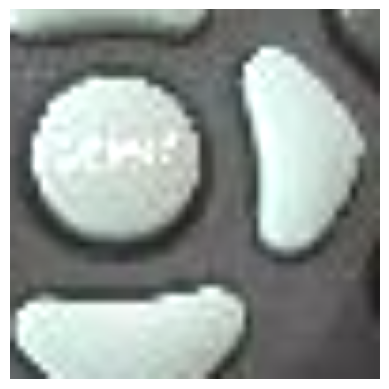

remote control, remote


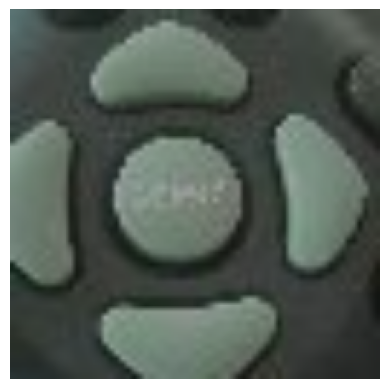

In [ ]:
# TEST CODE
%matplotlib inline

for images, labels in train_ds.take(1):
  print(one_hot_to_tinyimagenet_word(labels[0], wnids, wnid_to_words))
  plt.imshow(convert_back(images[0]).numpy())
  plt.axis("off")
  plt.show()

  print(one_hot_to_tinyimagenet_word(labels[128], wnids, wnid_to_words))
  plt.imshow(convert_back(images[128]).numpy())
  plt.axis("off")
  plt.show()

In [ ]:
class ResNetBlock(tfla.Layer):
  def __init__(self, out_dims):
    super().__init__()
    self.out_dims = out_dims

    self.Conv1 = tfla.Conv2D(out_dims // 4, 1, padding="same")
    self.BN1 = tfla.BatchNormalization()
    self.ReLU1 = tfla.ReLU()
    self.Conv2_not_downsample = tfla.Conv2D(out_dims // 4, 3, padding="same")
    self.Conv2_downsample = tfla.Conv2D(out_dims // 4, 3, strides=2, padding="same")
    self.BN2 = tfla.BatchNormalization()
    self.ReLU2 = tfla.ReLU()
    self.Conv3 = tfla.Conv2D(out_dims, 1, padding="same")
    self.BN3 = tfla.BatchNormalization()
    self.ReLU3 = tfla.ReLU()
    self.shortcut_downsample = tfla.Conv2D(out_dims, 1, strides=2, padding="same")
    self.shortcut_BN = tfla.BatchNormalization()
    self.shortcut_not_downsample = tfla.Conv2D(out_dims, 1, padding="same")

  def call(self, x, downsample=False):
    short_cut = x

    x = self.Conv1(x)
    x = self.BN1(x)
    x = self.ReLU1(x)

    if downsample:
      x = self.Conv2_downsample(x)
    else:
      x = self.Conv2_not_downsample(x)

    x = self.BN2(x)
    x = self.ReLU2(x)
    x = self.Conv3(x)
    x = self.BN3(x)

    if downsample:
      short_cut = self.shortcut_downsample(short_cut)
    else:
      if self.out_dims != short_cut.shape[-1]:
        short_cut = self.shortcut_not_downsample(short_cut)
    short_cut = self.shortcut_BN(short_cut)

    x = x + short_cut
    x = self.ReLU3(x)

    return x

In [ ]:
inputs = tfla.Input(shape=(224, 224, 3))

x = tfla.Conv2D(64, 7, strides=2, padding="same")(inputs)
x = tfla.BatchNormalization()(x)
x = tfla.ReLU()(x)
x = tfla.MaxPool2D(3, strides=2, padding="same")(x)
# current x shape:[B, 56, 56, 64]

for _ in range(3):
  x = ResNetBlock(out_dims=256)(x)
# current x shape:[B, 56, 56, 256]

x = ResNetBlock(out_dims=512)(x, downsample=True)
for _ in range(3):
  x = ResNetBlock(out_dims=512)(x)
# current x shape:[B, 28, 28, 512]

x = ResNetBlock(out_dims=1024)(x, downsample=True)
for _ in range(5):
  x = ResNetBlock(out_dims=1024)(x)
# current x shape:[B, 14, 14, 1024]

x = ResNetBlock(out_dims=2048)(x, downsample=True)
for _ in range(2):
  x = ResNetBlock(out_dims=2048)(x)
# current x shape:[B, 7, 7, 2048]

outputs = tfla.GlobalAveragePooling2D()(x)

encoder = tfm.Model(inputs, outputs)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'res_net_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'res_net_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'res_net_block_2', however the layer

In [ ]:
head_inputs = tfla.Input(shape=(2048,))

z = tfla.Dense(2048, use_bias=False)(head_inputs)
z = tfla.BatchNormalization()(z)
z = tfla.ReLU()(z)

head_outputs = tfla.Dense(128)(z)

projection_head = tfm.Model(head_inputs, head_outputs)

In [ ]:
inputs = tfla.Input(shape=(224, 224, 3))

x = encoder(inputs)
x = projection_head(x)

simclr_model = tfm.Model(inputs, x)

In [ ]:
simclr_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 2048)           │    23,632,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 128)            │     4,464,768 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,097,536 (107.18 MB)

 Trainable params: 28,017,792 (106.88 MB)

 Non-trainable params: 79,744 (311.50 KB)

In [ ]:
def nt_xent_loss(x, temperature=0.1):
  # x shape:[B, 128]
  B = tf.shape(x)[0]

  x = tf.math.l2_normalize(x, axis=1)
  # x shape:[B, B]
  x = tf.matmul(x, x, transpose_b=True)
  x = x / temperature

  pos_pair_distance = tf.shape(x)[0] // 2
  labels = tf.range(pos_pair_distance)
  # labels: [pos_pair_distance, pos_pair_distance + 1, ..., 0, 1, ...]
  labels = tf.concat([labels + pos_pair_distance, labels], axis=0)

  diagonal_mask = tf.eye(B)
  x = x - diagonal_mask * 1e9

  loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels, x)

  return tf.reduce_mean(loss), x, labels

In [ ]:
optimizer = tfo.AdamW(
    learning_rate=0.005,
    weight_decay=0.0001,
    beta_1=0.9,
    beta_2=0.999
)
optimizer.exclude_from_weight_decay = ["embedding", "positional", "bias", "normalization"]

In [ ]:
def top_1_accuracy(similarity_matrix, labels):
  predictions = tf.argmax(similarity_matrix, axis=1)
  labels = tf.cast(labels, tf.int64)

  return tf.reduce_mean(tf.cast(tf.equal(predictions, labels), tf.float32))

In [ ]:
@tf.function
def train_step(images, labels):
  with tf.GradientTape() as tape:
    x = simclr_model(images, training=True)
    loss, similarity_matrix, positional_labels = nt_xent_loss(x)

  gradients = tape.gradient(loss, simclr_model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, simclr_model.trainable_variables))

  accuracy = top_1_accuracy(similarity_matrix, positional_labels)

  return loss, accuracy

In [ ]:
for epoch in range(100):
  total_step_per_epoch = 0.0
  total_accuracy_per_epoch = 0.0
  total_loss_per_epoch = 0.0

  for step, (images, labels) in enumerate(train_ds):
    loss, accuracy = train_step(images, labels)
    total_step_per_epoch += 1
    total_accuracy_per_epoch += accuracy
    total_loss_per_epoch += loss
    #if step % 50 == 0:
    #  print(f"loss:{loss}.    top-1-accuracy:{accuracy}\n")

  print(f"epoch:{epoch}.   loss:{total_loss_per_epoch / total_step_per_epoch}.      accuracy:{total_accuracy_per_epoch / total_step_per_epoch}\n")

epoch:0.   loss:3.9332313537597656.      accuracy:0.16638027131557465

epoch:1.   loss:2.397996664047241.      accuracy:0.48316115140914917

epoch:2.   loss:1.6969610452651978.      accuracy:0.658397912979126

epoch:3.   loss:1.3189648389816284.      accuracy:0.7529571652412415

epoch:4.   loss:1.0782537460327148.      accuracy:0.8117057681083679

epoch:5.   loss:0.9415755271911621.      accuracy:0.8457180857658386

epoch:6.   loss:0.8506628274917603.      accuracy:0.8669976592063904

epoch:7.   loss:0.7741661071777344.      accuracy:0.8833519816398621

epoch:8.   loss:0.7323757410049438.      accuracy:0.8921485543251038

epoch:9.   loss:0.6917348504066467.      accuracy:0.901864230632782

epoch:10.   loss:0.6558281183242798.      accuracy:0.9085277915000916

epoch:11.   loss:0.6250167489051819.      accuracy:0.9149366617202759

epoch:12.   loss:0.6091898083686829.      accuracy:0.9187080264091492

epoch:13.   loss:0.5785953402519226.      accuracy:0.9245973825454712

epoch:14.   loss: